Analysis into if cmems or OSCAR is more accurate based off of the initial abbility to predict the the dFADs speeds

- Start by using compairson of CMEMs and the dFADs speeds at current time 
    Produce plot of inital cmems speed errors vs leadtime errors. 
    create a list of all the innital speed errors 


In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
from importlib import reload
import functions.funcs as funcs 
reload(funcs)
import matplotlib.pyplot as plt

In [106]:
ds = gpd.read_parquet(r"Data\MappedOSCAR_SAT_MI_Cleanedspeeds.parquet") 
#ds = funcs.querry_date_range(ds, pd.Timestamp("2024-1-1"), pd.Timestamp("2025-1-1"))
ds = ds.reset_index(drop = True)
fc = pd.read_csv("Parcels/saved_output/cmems_static2024.csv")
fc1 = pd.read_csv("Parcels/saved_output/OSCAR_2024.csv")

fc2 = pd.read_csv("Parcels/saved_output/optimal_cmems_OSCAR_2024.csv")
fc3 = pd.read_csv("Parcels/saved_output/No_forecast.csv")
fc4 = pd.read_csv("Parcels/saved_output/cmems_static2023.csv")
fc5 = pd.read_csv("Parcels/saved_output/No_forecast2023.csv")
fc6 = pd.read_csv("Parcels/saved_output/cmems_static2022.csv")
fc["Time"] = pd.to_datetime(fc["Time"])
fc['error_km'] = funcs.haversine_df(fc, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc1["Time"] = pd.to_datetime(fc1["Time"])
fc1['error_km'] = funcs.haversine_df(fc1, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc2["Time"] = pd.to_datetime(fc2["Time"])
fc2["error_km"] = funcs.haversine_df(fc2, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc3["Time"] = pd.to_datetime(fc3["Time"])
fc3["error_km"] = funcs.haversine_df(fc3, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc4["Time"] = pd.to_datetime(fc4["Time"])
fc4["error_km"] = funcs.haversine_df(fc4, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc5["Time"] = pd.to_datetime(fc5["Time"])
fc5["error_km"] = funcs.haversine_df(fc5, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc6["Time"] = pd.to_datetime(fc6["Time"])
fc6["error_km"] = funcs.haversine_df(fc6, "lat_true", "lon_true", "lat_forcast", "lon_forcast")

ds.columns

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined', 'mapped_v',
       'mapped_u', 'mapped_v_oscar', 'mapped_u_oscar'],
      dtype='str')

In [3]:

print(fc1.columns)

Index(['Unnamed: 0', 'BuoyID', 'Time', 'lat_true', 'lon_true', 'lat_forcast',
       'lon_forcast', 'leadtime', 'error_km'],
      dtype='str')


In [4]:
fc2.query("leadtime == 0").shape

(8429, 11)

In [5]:
def add_starttime(fc):
    fc["starttime"] = (fc["Time"] - pd.to_timedelta(fc["leadtime"], unit= "hours")).dt.round("min")
    return fc

In [6]:
longlist = pd.DataFrame({})
longlist["Time"] = funcs.Column_to_List(ds, "TimeStamp", idlist = False)
longlist["lats"], longlist["lons"] = funcs.list_of_latlon(ds, False)
longlist["x_speed"] = funcs.Column_to_List(ds, "x_speed", idlist = False)
longlist["y_speed"] = funcs.Column_to_List(ds, "y_speed", idlist = False)
longlist["v_mapped"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v", idlist = True)
longlist["v_mapped_OSCAR"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v_oscar", idlist = True)
longlist["u_mapped"] = funcs.Column_to_List(ds, "mapped_u", idlist = False)
longlist["u_mapped_OSCAR"] = funcs.Column_to_List(ds, "mapped_u_oscar", idlist = False)
longlist.Time = pd.to_datetime(longlist.Time)
# mask = (longlist.Time > pd.Timestamp('2023-12-31')) 
# longlist = longlist[mask].reset_index(drop = True)
# longlist = longlist[longlist.Time < pd.Timestamp('2025-1-1')].reset_index(drop = True)

In [7]:
## maps the True dFAD dFADs speeds onto 
def merge_forecast_true(fc, longlist):
    merged = pd.merge_asof(
    fc.sort_values('Time'),
    longlist.sort_values('Time'),
    on='Time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
    )
    return merged

merged = merge_forecast_true(fc, longlist)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values('leadtime') ## was time not sure if this changes results in later analysis
merged["initial_speed"] = merged.groupby(by=["BuoyID", "starttime"])['speed'].transform('first')
## plot for just 24 hours 
bins = np.linspace(0,8*24,2*24+1)
merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = merged["lead_bins"].unique()
a  =binlist[7] ## list of bin intervals 
print(a)
mergedhr = merged.groupby("lead_bins").get_group(a)
##now group by speeds and take a mean.
speedbins = np.linspace(0,mergedhr.initial_speed.max(),25 )
mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()

(24.0, 28.0]


### Speed Corrilations with errors.

In [8]:
def inital_speed_binning(merged: pd.DataFrame, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(0,mergedhr.initial_speed.max(),25)
    mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
    binned_errors = mergedhr.groupby("speed_bin")["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = inital_speed_binning(merged,8)

(28.0, 32.0]


(0.0, 4.0]
(4.0, 8.0]
(8.0, 12.0]
(12.0, 16.0]
(16.0, 20.0]
(20.0, 24.0]
(24.0, 28.0]
(28.0, 32.0]
(32.0, 36.0]
(36.0, 40.0]


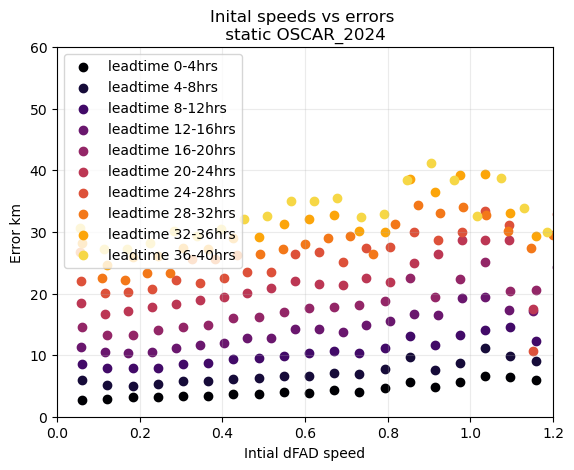

In [9]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
for i in range(10):
    speedbins, binned_errors = inital_speed_binning(merged,i+1)
    ax.scatter(speedbins[1:], binned_errors, label=f"leadtime {i*4}-{(i+1)*4}hrs", color=cmap(i/10))
ax.set_ylabel("Error km")
ax.set_xlabel("Intial dFAD speed")
ax.set_xlim(0,1.2)
ax.set_ylim(0,60)
ax.set_title("Inital speeds vs errors \n static OSCAR_2024 ")
ax.grid(alpha = 0.25)
ax.legend()

### analyzing optimal forecasting dataset

In [10]:
### plot simple time series of Percent cmems or OSCAR

fc2i= fc2.query("leadtime == 0").reset_index(drop = True).sort_values("Time")
fc2i["Day"] = fc2i.Time.dt.date
print(f"Fraction of cmems forecasts : {fc2i.query("model == 'cmems'")["model"].count()/fc2i.model.count() :0.4}")

percentcmems = fc2i.groupby("Day").apply(lambda x: (x["model"] == "cmems").sum() / len(x) * 100)
percentcmems = percentcmems.to_frame().rename(columns = {0: "cmems"})
percentcmems["rolling"] = percentcmems.cmems.rolling(7).mean()

Fraction of cmems forecasts : 0.3105


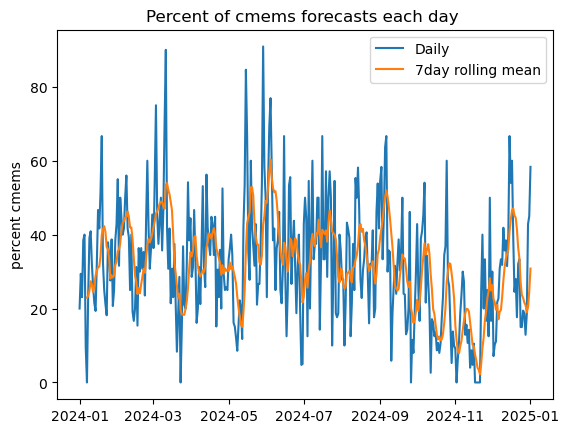

In [11]:
fig, ax = plt.subplots()
ax.plot(percentcmems.index, percentcmems.values, label = ["Daily", "7day rolling mean"])
ax.set_ylabel("percent cmems")
ax.set_title("Percent of cmems forecasts each day ")
ax.legend()

In [12]:
### merging forecast data with mapped speeds
oscar = fc2.query("model == 'OSCAR'").reset_index(drop = True)
oscar_merged = merge_forecast_true(oscar, longlist)
oscar_merged = oscar_merged.rename(columns= {"u_mapped_OSCAR" : "u_mapped_comb", "v_mapped_OSCAR": "v_mapped_comb"})

cmems = fc2.query("model =='cmems'").reset_index(drop = True)
cmems_merged = merge_forecast_true(cmems, longlist)
cmems_merged = cmems_merged.rename(columns= {"u_mapped" : "u_mapped_comb", "v_mapped": "v_mapped_comb"})
fc_opt = pd.concat([cmems_merged, oscar_merged])

In [13]:
fc_opt["projection"] = (fc_opt.y_speed * fc_opt.v_mapped_comb)+ (fc_opt.x_speed * fc_opt.u_mapped_comb)
fc_opt["projection"]  = fc_opt["projection"]/(fc_opt.x_speed**2 +fc_opt.y_speed**2 )**(1/2)
fc_opt["initial_angle"] = fc_opt["projection"]/(fc_opt.u_mapped_comb**2 +fc_opt.v_mapped_comb**2 )**(1/2)
fc_opt["initial_angle"] = np.arccos(fc_opt["initial_angle"])*180/np.pi
fc_opt_saved = fc_opt.copy()

### Projection of dFAD onto the model speeds vs errors. 


In [14]:
def calc_projection_initial_angle(merged, sufix = None):
    projection = "projection"
    angle = "angle"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        projection +=sufix
        angle +=sufix
        u += sufix
        v+= sufix 
    merged[projection] = (merged.y_speed * merged[v])+ (merged.x_speed * merged[u])
    merged[projection]  = merged[projection]/(merged.x_speed**2 +merged.y_speed**2 )**(1/2)
    merged[angle] = merged[projection]/(merged[u]**2 +merged[v]**2 )**(1/2)
    merged[angle] = np.arccos(merged[angle])*180/np.pi
    merged = merged.sort_values("leadtime")
    merged["initial_"+angle] =  merged.groupby(["BuoyID", "starttime"])[angle].transform("first")
    merged["initial_"+projection] = merged.groupby(["BuoyID", "starttime"])[projection].transform("first")
    return merged

def calc_intial_speed_dif(merged, sufix= None):
    initial_speed_dif_mag = "initial_speed_dif_mag" 
    speed_dif_mag = "speed_dif_mag"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        initial_speed_dif_mag +=sufix
        speed_dif_mag +=sufix
        u += sufix
        v+= sufix 
    merged[speed_dif_mag] = np.sqrt((merged.x_speed - merged[u])**2 + (merged.y_speed - merged[v])**2)
    merged[initial_speed_dif_mag] = merged.groupby(["BuoyID", "starttime"])[speed_dif_mag].transform("first")
    return merged

merged = merge_forecast_true(fc, longlist)
merged = add_starttime(merged)
merged = calc_projection_initial_angle(merged)
merged = calc_projection_initial_angle(merged, sufix = "_OSCAR")
merged = calc_intial_speed_dif(merged)
merged = calc_intial_speed_dif(merged, "_OSCAR")

def Projection_binning(merged: pd.DataFrame, label:str, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique().sort_values()
    a  =binlist[binindex] ## list of bin intervals 
    print(a)
    mergedhr = merged.groupby("lead_bins").get_group(a)
    ##now group by speeds and take a mean.
    speedbins = np.linspace(mergedhr[label].min(),mergedhr[label].max(),25)
    mergedhr["projection_bin"] = pd.cut(mergedhr[label], speedbins)
    binned_errors = mergedhr.groupby("projection_bin")["error_km"].mean()
    return speedbins, binned_errors



(48.0, 52.0]
(52.0, 56.0]
(56.0, 60.0]
(60.0, 64.0]
(64.0, 68.0]
(68.0, 72.0]
(72.0, 76.0]
(76.0, 80.0]
(80.0, 84.0]
(84.0, 88.0]
(88.0, 92.0]
(92.0, 96.0]


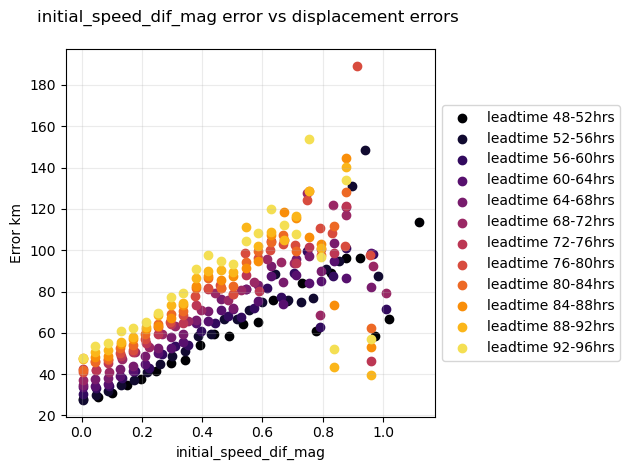

In [15]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
ofset = 12 ## ofsets in 4 hour incruments 
timerange = 12
variable = "initial_speed_dif_mag"
for i in range(timerange):
    speedbins, binned_errors = Projection_binning(merged,variable, i+ofset)
    ax.scatter(speedbins[binned_errors.index.codes], binned_errors, label=f"leadtime {(i+ofset)*4}-{(i+ofset+1)*4}hrs", color=cmap(i/timerange))
ax.set_ylabel("Error km")
ax.set_xlabel(variable)
#ax.set_xlim(0,1)
#ax.set_ylim(0,60)
ax.set_title(f"{variable} error vs displacement errors \n ")
ax.grid(alpha = 0.25)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()

### initial Speed and angle Corrialtion

Text(0.5, 1.0, 'Mean Error vs Initial Angle and Speed Difference \n Number are amount points in each bin \n Errors at leadtime: 72 hrs')

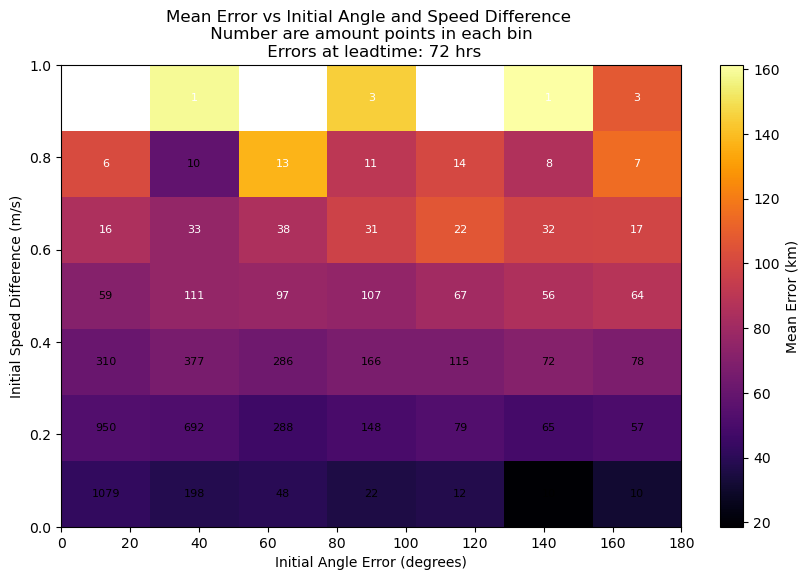

In [16]:
## making a plot of intial angle error and speed error, 
# need to calculate speed error 
# merged.initial_speed is the speed of dFAD at time zero. 

angle_var = "initial_angle"
speed_var = "initial_speed_dif_mag"

merged = merged.sort_values(by = "leadtime")
target_leadtime = 24*3-2
merged_start = merged.query("leadtime > @target_leadtime").drop_duplicates(subset = ["BuoyID", "starttime"])
target_leadtime_upper = target_leadtime + 12
merged_start = merged_start.query("leadtime < @target_leadtime_upper") 

# Create 2D bins for initial_angle and initial_speed_dif_mag
angle_bins = np.linspace(0, 180, 8)
speed_bins = np.linspace(0, 1, 8)

# Bin the data
merged_start["angle_bin"] = pd.cut(merged_start[angle_var], angle_bins)
merged_start["speed_bin"] = pd.cut(merged_start[speed_var], speed_bins)

# Calculate mean error for each 2D bin
binned_data = merged_start.groupby(["angle_bin", "speed_bin"]).agg({"error_km": "mean"}).reset_index()
binned_pivot = binned_data.pivot_table(index="speed_bin", columns="angle_bin", values="error_km")

# Create meshgrid for pcolormesh

angle_mesh, speed_mesh = np.meshgrid(angle_bins, speed_bins)

# Convert binned_pivot to 2D array for pcolormesh
error_values = binned_pivot.values

fig, ax = plt.subplots(figsize=(10, 6))
pcm = ax.pcolormesh(angle_mesh, speed_mesh, error_values, cmap="inferno", shading="auto")
cbar = fig.colorbar(pcm, ax=ax, label="Mean Error (km)")
#pcm.set_clim(10,120)

counts = merged_start.groupby(["angle_bin", "speed_bin"]).size().reset_index(name="count")
counts_pivot = counts.pivot(index="speed_bin", columns="angle_bin", values="count")
count_values = counts_pivot.values
angle_centers = (angle_bins[:-1] + angle_bins[1:]) / 2
speed_centers = (speed_bins[:-1] + speed_bins[1:]) / 2
angle_cent_mesh, speed_cent_mesh = np.meshgrid(angle_centers, speed_centers)
for (i, j), val in np.ndenumerate(count_values):
    cnt = count_values[i, j]
    if np.isnan(cnt):
        continue
    x = angle_cent_mesh[i, j]
    y = speed_cent_mesh[i, j]
    err = error_values[i, j] if not np.isnan(error_values[i, j]) else 0
    text_color = "white" if err > (pcm.get_clim()[1] * 0.45) else "black"
    ax.text(x, y, int(cnt), ha="center", va="center", color=text_color, fontsize=8)
# <-- END INSERTION

ax.set_xlabel("Initial Angle Error (degrees)")
ax.set_ylabel("Initial Speed Difference (m/s)")
ax.set_title(f"Mean Error vs Initial Angle and Speed Difference \n Number are amount points in each bin \n Errors at leadtime: {target_leadtime +2} hrs")

#### removing initial angle varience 

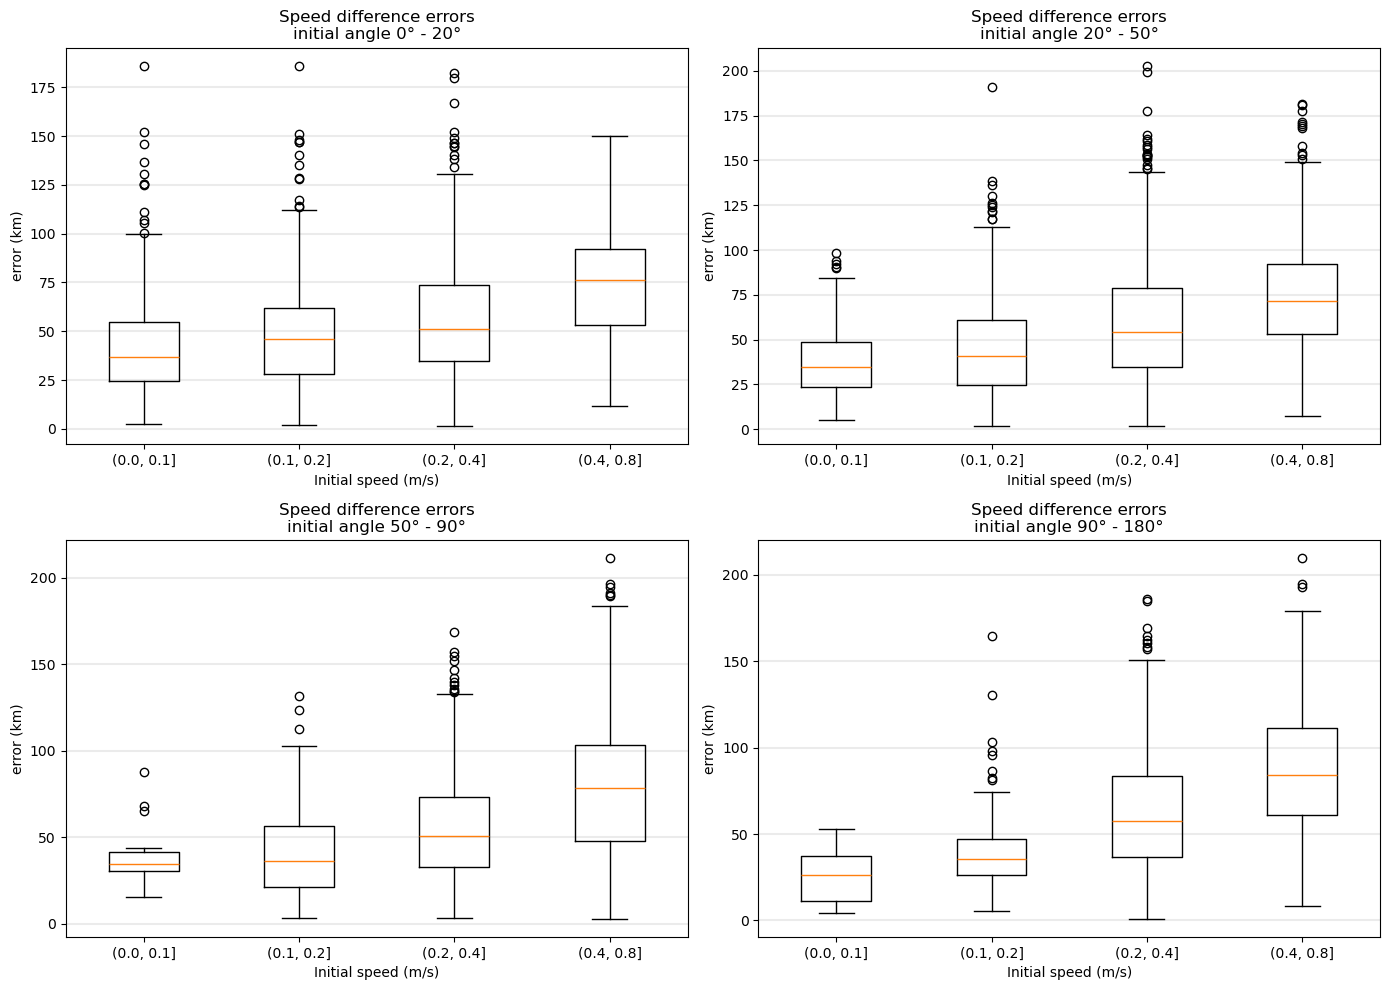

In [17]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
params = [
    {"lowerbound": 0, "higherbound": 20, "ax": ax1},
    {"lowerbound": 20, "higherbound": 50, "ax": ax2},
    {"lowerbound": 50, "higherbound": 90, "ax": ax3},
    {"lowerbound": 90, "higherbound": 180, "ax": ax4},
]

for i, param in enumerate(params):
    lowerbound = param["lowerbound"]
    higherbound = param["higherbound"]
    ax = param["ax"]
    
    angle_slice = merged_start[merged_start.initial_angle > lowerbound]
    angle_slice = angle_slice[angle_slice.initial_angle < higherbound].reset_index(drop=True)
    bins = np.linspace(0, 0.8, 4)
    bins = np.array([0, 0.1, 0.2, 0.4, 0.8])
    angle_slice["speed_bin"] = pd.cut(angle_slice.initial_speed_dif_mag, bins)
    grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
    bins_list = angle_slice.speed_bin.unique().sort_values()
    
    ax.boxplot(grouped_speed_lists, tick_labels=bins_list[:-1])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial speed (m/s)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Speed difference errors\ninitial angle {lowerbound}° - {higherbound}°")
    # ax.set_ylim(0, 150)

plt.tight_layout()

# lowerbound = 0
# higherbound = 40
# angle_slice = merged_start[merged_start.initial_angle > lowerbound]
# angle_slice = angle_slice[angle_slice.initial_angle < higherbound].reset_index(drop = True)
# bins = np.linspace(0,0.8,4)
# angle_slice["speed_bin"] = pd.cut(angle_slice.initial_speed_dif_mag, bins)
# grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
# bins_list = angle_slice.speed_bin.unique().sort_values()
# print(len(grouped_speed_lists))
# fig, ax = plt.subplots()
# ax.boxplot(grouped_speed_lists, tick_labels = bins_list[:-1])
# ax.grid(axis = "y", alpha = 0.25, lw = 1.5)
# ax.set_xlabel("Initial speed speed m/s")
# ax.set_ylabel("error km")
# ax.set_title(f"speed differance errors \n with intial angle errors of {lowerbound} - {higherbound}")

#### Removing Initial Speed, Focusing on just inital angle varience. 


4 4
4 4
4 4
4 4


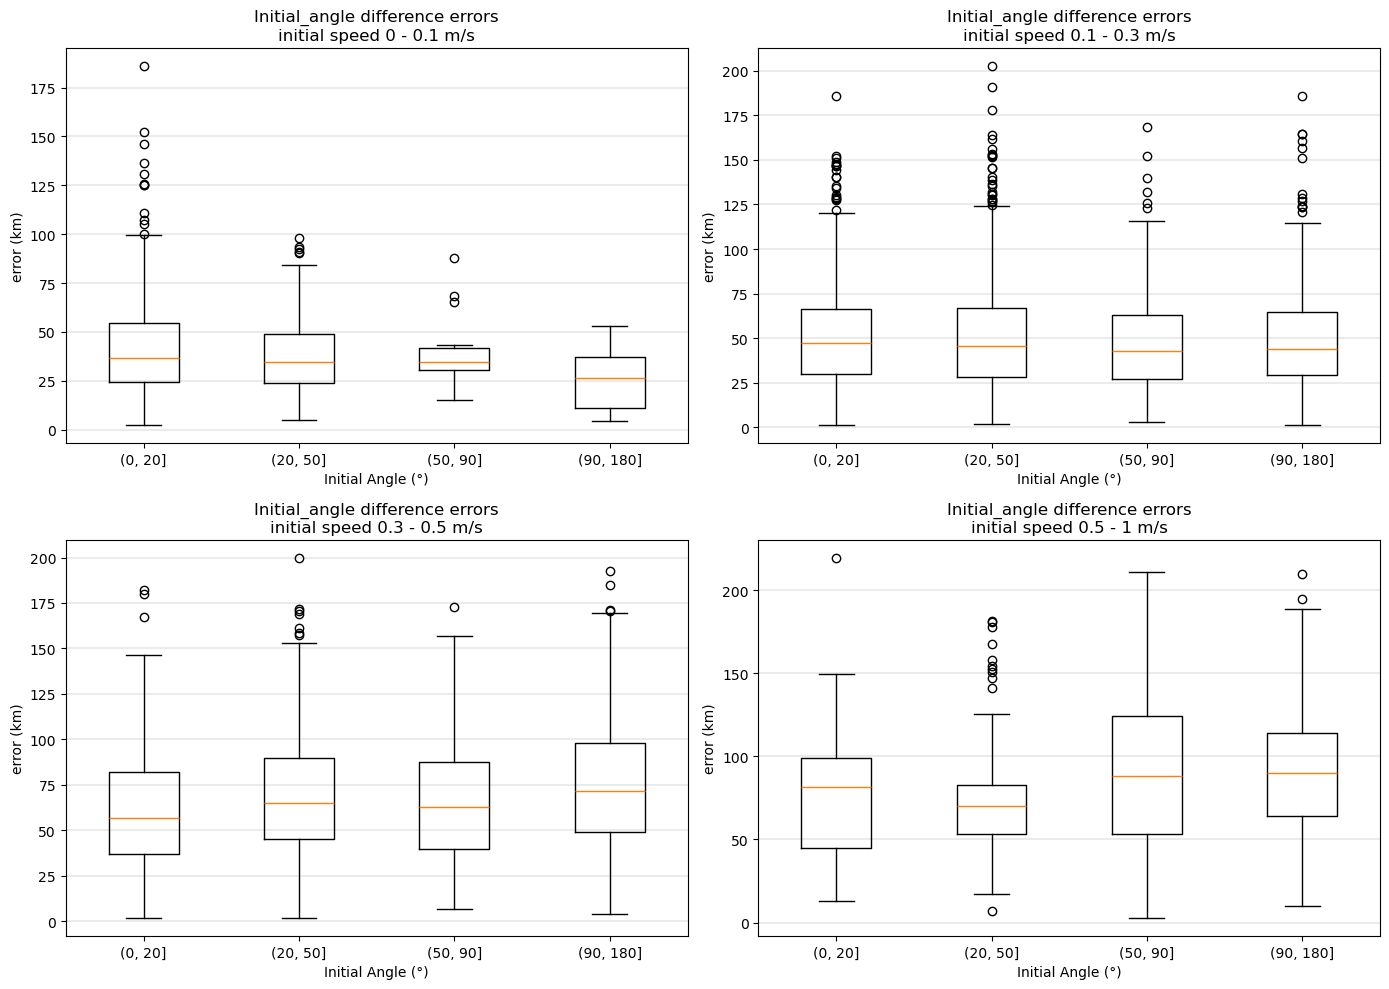

In [18]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
params = [
    {"lowerbound": 0, "higherbound": 0.1, "ax": ax1},
    {"lowerbound": 0.1, "higherbound": 0.3, "ax": ax2},
    {"lowerbound": 0.3, "higherbound": 0.5, "ax": ax3},
    {"lowerbound": 0.5, "higherbound": 1, "ax": ax4},
]

for i, param in enumerate(params):
    lowerbound = param["lowerbound"]
    higherbound = param["higherbound"]
    ax = param["ax"]
    speed_slice = merged_start[merged_start.initial_speed_dif_mag > lowerbound]
    speed_slice = speed_slice[speed_slice.initial_speed_dif_mag < higherbound].reset_index(drop = True)
    bins = np.linspace(0,170,6)
    bins = np.array([0, 20, 50, 90, 180])
    speed_slice["angle_bin"] = pd.cut(speed_slice.initial_angle, bins)
    grouped_angle_lists = [group.tolist() for name, group in speed_slice.groupby("angle_bin")["error_km"]]
    bins_list = speed_slice.angle_bin.unique().sort_values()
    print(len(grouped_angle_lists), len(bins_list))
    ax.boxplot(grouped_angle_lists, tick_labels=bins_list[:])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial Angle (°)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Initial_angle difference errors\ninitial speed {lowerbound} - {higherbound} m/s")
    #ax.set_ylim(0, 150)
fig.tight_layout()

#### Using Quartile linear regression to predict errors of each quartile

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


Text(0.5, 1.0, 'quantile regression with inital angle and speed differnces \n intial angle error: 60')

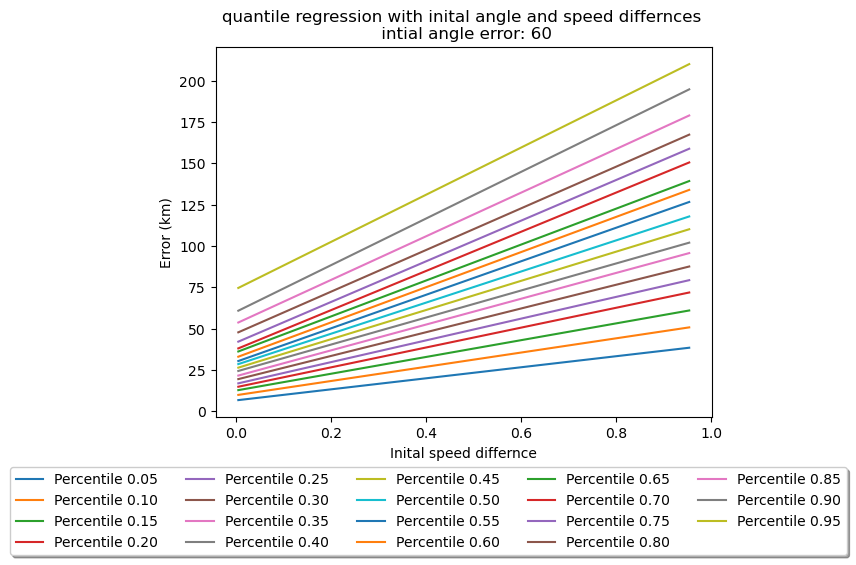

In [19]:
import statsmodels.formula.api as smf

merged_start ## this is all errors at 72 hours. 

model = smf.quantreg("error_km ~  initial_angle+ initial_speed_dif_mag ", merged_start)
quartiles_range = np.linspace(0.05, 0.95, 19)
print(quartiles_range)
initial_speed_dif_mag = np.arange(merged_start.initial_speed_dif_mag.min(), merged_start.initial_speed_dif_mag.max(), 0.05)
target_angle = 60
models = []

fig, ax = plt.subplots()
for n in quartiles_range: 
    res = model.fit(q=n)
    models.append(res)
    y = res.params["Intercept"] + res.params["initial_speed_dif_mag"]*initial_speed_dif_mag + res.params["initial_angle"]*target_angle
    ax.plot(initial_speed_dif_mag, y, label =f"Percentile {n:.2f}")

fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
        fancybox=True, shadow=True, ncol=5)

ax.set_xlabel("Inital speed differnce")
ax.set_ylabel("Error (km)")
ax.set_title(f"quantile regression with inital angle and speed differnces \n intial angle error: {target_angle}")

    


Intercept         39.207096
initial_angle     -0.027384
initial_speed    118.463087
Name: 0.7, dtype: float64


Text(0.5, 1.0, 'Perdicted error Based off Inital Speed and intial Angle Error\n Quantile: 0.70\n at leadtime: 72 \n  z = 39.21 +-0.027* X + 118.46 * Y ')

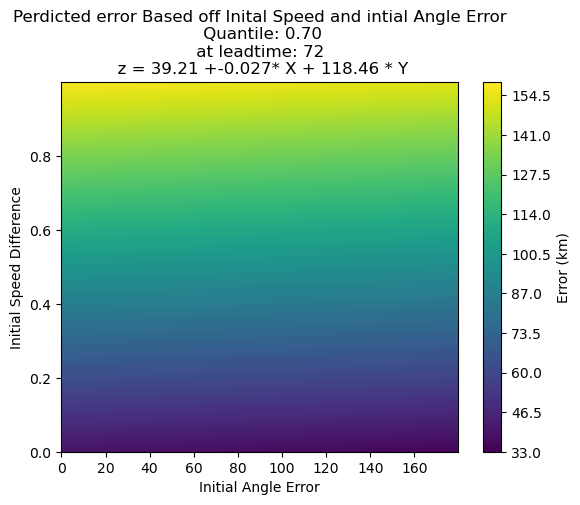

In [20]:
## generating 2d plot 
intercepts = []
initial_angle_a  = []
initial_speed_b = []
for model in models: 
    initial_angle_a.append(model.params["initial_angle"])
    intercepts.append(model.params["Intercept"])
    initial_speed_b.append(model.params["initial_speed_dif_mag"])

quartiles = pd.DataFrame({ "Intercept": intercepts, "initial_angle": initial_angle_a,"initial_speed": initial_speed_b  }, index = quartiles_range)
ispeed_range = np.arange(0,1,0.001)
iangle_range = np.arange(0,180,0.18)
target = 13
q = quartiles.iloc[target]
quan= quartiles.index[target] 
print(q)
X,Y = np.meshgrid( iangle_range, ispeed_range)
error_values = q.Intercept  + q.initial_angle*X + q.initial_speed*Y
fig, ax = plt.subplots()
cbar = ax.contourf(X,Y,error_values, levels = 100)
fig.colorbar(cbar, label = "Error (km)")
ax.set_xlabel("Initial Angle Error")
ax.set_ylabel("Initial Speed Difference")
ax.set_title(f"Perdicted error Based off Inital Speed and intial Angle Error\n Quantile: {quan:.2f}\n at leadtime: {target_leadtime+2} \n  z = { q.Intercept:.2f} +{q.initial_angle:.3f}* X + {q.initial_speed:.2f} * Y ")


In [21]:
quartiles.index[9]

np.float64(0.49999999999999994)

In [22]:
res.params["Intercept"]
res.params["initial_angle"]

np.float64(-0.01567003586629312)

In [23]:
merged_start

,Unnamed: 0,BuoyID,Time,lat_true,lon_true,lat_forcast,lon_forcast,leadtime,error_km,lats,...,angle_OSCAR,initial_angle_OSCAR,initial_projection_OSCAR,speed_dif_mag,initial_speed_dif_mag,speed_dif_mag_OSCAR,initial_speed_dif_mag_OSCAR,lead_bins,angle_bin,speed_bin
232282,70,SLX+487665,2024-12-13 22:44:00,4.60237,-162.21342,4.416409,-162.394836,70.016667,28.844301,4.60237,...,149.063111,95.053129,-0.022096,0.232467,0.364149,0.245503,0.371818,"(68.0, 72.0]","(77.143, 102.857]","(0.286, 0.429]"
111610,18,SLX+445951,2024-05-23 01:33:00,6.01815,-162.08377,6.172122,-162.119379,70.050000,17.567803,6.01815,...,5.204045,20.308875,0.130150,0.088574,0.123770,0.033490,0.135226,"(68.0, 72.0]","(0.0, 25.714]","(0.0, 0.143]"
166263,70,SLX+466491,2024-08-21 22:56:00,5.20778,-163.36222,5.576589,-162.572597,70.100000,96.555118,5.20778,...,29.973933,8.770156,0.322365,0.222749,0.193528,0.092629,0.120324,"(68.0, 72.0]","(0.0, 25.714]","(0.143, 0.286]"
214131,18,SLX+456584,2024-11-07 22:12:00,5.82912,-162.59627,6.146444,-162.584064,70.166667,35.310636,5.82912,...,3.762413,49.047369,0.084428,0.236061,0.223119,0.053235,0.412363,"(68.0, 72.0]","(0.0, 25.714]","(0.143, 0.286]"
112266,19,SLX+445951,2024-05-24 01:42:00,5.99672,-162.21438,6.092858,-162.062638,70.200000,19.895172,5.99672,...,109.372597,11.225447,0.135419,0.100427,0.203392,0.152855,0.167884,"(68.0, 72.0]","(0.0, 25.714]","(0.143, 0.286]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105775,18,SLX+367060,2024-05-09 11:42:00,6.37255,-162.28905,6.686638,-161.434472,80.016667,100.661141,6.37255,...,19.523306,14.593653,0.383169,0.394541,0.436645,0.293509,0.263901,"(80.0, 84.0]","(0.0, 25.714]","(0.429, 0.571]"
186370,12,SLX+434973,2024-10-03 08:50:00,6.43780,-162.42318,5.906034,-160.908739,80.016667,177.556283,6.43780,...,89.620547,76.306079,0.140505,0.748456,0.747273,0.619309,0.593213,"(80.0, 84.0]","(51.429, 77.143]","(0.714, 0.857]"
229872,3,SLX+479934,2024-12-12 08:05:00,5.37507,-160.71980,6.519331,-160.931100,80.016667,129.364171,5.37507,...,162.518680,2.458597,0.429403,0.098674,0.204896,0.223012,0.097666,"(80.0, 84.0]","(0.0, 25.714]","(0.143, 0.286]"
170002,52,SLX+466491,2024-08-27 08:55:00,4.69885,-163.08103,4.643518,-162.274508,80.083333,89.594796,4.69885,...,111.481314,2.928204,0.322442,0.263116,0.124299,0.220316,0.016544,"(80.0, 84.0]","(0.0, 25.714]","(0.0, 0.143]"


#### Developing a better analysis between initial angle error and initial speed difference 

1) split into meaningful quadrents. 
    - quadrents should include a statistically significant amount of data. 
        - quaderrents areas do not have to be the same size 
        -   width and high and quadrent do not need to be the same size also
            - size needs to be showuing error differances greater than bootstapping distributions. satistically significnat in each direction of the axis. 
            so we can confidently say that moving in one direction has a diffent error. 
    - could do boot strapping to show uncertainties because of forecasts generated. 
2) within each quadrent generate the expected error spreads. 
3) 

In [24]:
## checking making thing the initial 

merged_leadtime = merged.query("leadtime == 0 ")
# print(merged_leadtime[["initial_speed_dif_mag", "BuoyID"]].sort_index().head(40))
# print(merged_start[["initial_speed_dif_mag", "BuoyID"]].sort_index().head(20))
grouped = merged.groupby(["BuoyID", "starttime"])

# Method 1: Get a specific group by name (tuple of group keys)
first_group_name = ('ISD+496035', pd.Timestamp('2024-11-07 00:01:00'))
first_group = grouped.get_group(first_group_name)

# Method 2: Iterate and get the nth group
n = 0  # Get first group (0-indexed)
for i, (name, group) in enumerate(grouped):
    if i == n:
        first_group = group
        first_group_name = name
        break

# Method 3: Convert to list of groups (use with caution on large datasets)
groups_list = [group for name, group in grouped]
first_group = groups_list[10]
first_group

,Unnamed: 0,BuoyID,Time,lat_true,lon_true,lat_forcast,lon_forcast,leadtime,error_km,lats,...,initial_projection,projection_OSCAR,angle_OSCAR,initial_angle_OSCAR,initial_projection_OSCAR,speed_dif_mag,initial_speed_dif_mag,speed_dif_mag_OSCAR,initial_speed_dif_mag_OSCAR,lead_bins
223377,0,ISD+496040,2024-12-03 03:42:00,5.22988,-160.98070,NaN,NaN,0.000000,NaN,5.22988,...,0.217688,0.471695,19.293885,19.293885,0.471695,0.448930,0.44893,0.216152,0.216152,NaN
223502,1,ISD+496040,2024-12-03 07:42:00,5.27408,-160.93570,5.282417,-160.997348,4.000000,6.888540,5.27408,...,0.217688,0.426025,25.043063,19.293885,0.471695,0.536246,0.44893,0.204795,0.216152,"(0.0, 4.0]"
223624,2,ISD+496040,2024-12-03 11:42:00,5.31215,-160.88925,5.332894,-161.007077,8.000000,13.247626,5.31215,...,0.217688,0.367965,31.197235,19.293885,0.471695,0.561437,0.44893,0.238751,0.216152,"(4.0, 8.0]"
223744,3,ISD+496040,2024-12-03 15:43:00,5.34098,-160.84148,5.380378,-161.008128,12.016667,18.962401,5.34098,...,0.217688,0.304068,39.849861,19.293885,0.471695,0.593493,0.44893,0.280221,0.216152,"(12.0, 16.0]"
223865,4,ISD+496040,2024-12-03 19:45:00,5.38520,-160.78440,5.425141,-161.000024,16.050000,24.279378,5.38520,...,0.217688,0.313225,31.623988,19.293885,0.471695,0.631001,0.44893,0.298976,0.216152,"(16.0, 20.0]"
223964,5,ISD+496040,2024-12-03 23:41:00,5.43168,-160.72497,5.465689,-160.986625,19.983333,29.209100,5.43168,...,0.217688,0.308294,27.934980,19.293885,0.471695,0.655878,0.44893,0.317233,0.216152,"(16.0, 20.0]"
224103,6,ISD+496040,2024-12-04 03:42:00,5.46245,-160.67027,5.504343,-160.968793,24.000000,33.369081,5.46245,...,0.217688,0.307884,32.629310,19.293885,0.471695,0.620824,0.44893,0.259241,0.216152,"(20.0, 24.0]"


In [25]:
## remove duplicate forecasts
def add_inital_time(ds:pd.DataFrame):
    """adds intial time of forecast (time - leadtime) and changes collumns to pd.DateTime objects"""
    ds["Time"] = pd.to_datetime(ds["Time"])
    ds["initial_time"] =  ds["Time"] - pd.to_timedelta(ds["leadtime"], unit = "hours")
    ds["initial_time"] = ds["initial_time"].dt.round(freq = "min")
    return ds
merged = add_inital_time(merged)
merged_clean = merged.drop_duplicates(subset=['BuoyID', 'initial_time', 'leadtime'], keep='first')

8429

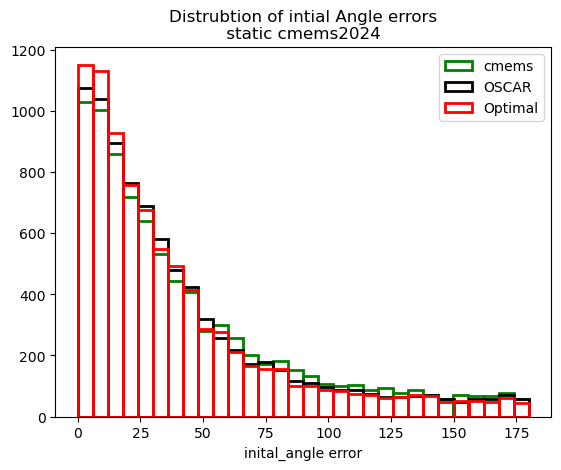

In [26]:
### distribution of inittial error speeds. 
initial_speeds = merged_clean.query("leadtime == 0")
initial_speeds_opt = fc_opt.query("leadtime == 0")
Greater90 = initial_speeds.query("initial_angle > 90")["initial_angle"].count()
fig, ax =plt.subplots()
ax.hist(initial_speeds.initial_angle, 30, fill= None, edgecolor = "g", lw =2, label = "cmems")
ax.hist(initial_speeds.initial_angle_OSCAR, 30, fill= None, edgecolor = "k", lw = 2, label = "OSCAR")
ax.hist(initial_speeds_opt.initial_angle, 30, fill= None, edgecolor = "r", lw = 2, label = "Optimal")
ax.set_xlabel("inital_angle error")
ax.set_title("Distrubtion of intial Angle errors\n static cmems2024 ")
ax.legend()
Greater90/initial_speeds.initial_angle.count()
initial_speeds.shape[0]
initial_speeds_opt.shape[0]

In [27]:
## checking number of forecasts 
print(initial_speeds.shape, initial_speeds_opt.shape)

(8429, 32) (8429, 23)


### Time Series of Errors Looking at seasonality

In [28]:

bins = np.linspace(0,8*24,2*24+1)
fc["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = fc["lead_bins"].unique()

def Forecast_timeseries(ds:pd.DataFrame, window:int, bin)-> pd.DataFrame:
    bins = np.linspace(0,8*24,2*24+1)
    ds["lead_bins"] = pd.cut(ds["leadtime"], bins)
    # (24.0, 28.0]
    fc_grouped = ds.groupby("lead_bins")
    fc24 = fc_grouped.get_group(a)
    fc24["Day"] = fc24.Time.dt.date
    ts24 = fc24.groupby("Day")["error_km"].mean()
    ts24 = ts24.to_frame("error_km").reset_index(drop= False)
    ts24["rolling"] = ts24["error_km"].rolling(window).mean()
    return ts24

In [29]:
window = 30
a = binlist[18]
print(a)
fcts = Forecast_timeseries(fc, window , a)
fcts2 = Forecast_timeseries(fc2,window, a)
fcts3 = Forecast_timeseries(fc3, window, a)

fcts4 = Forecast_timeseries(fc4, window, a)
fcts5 = Forecast_timeseries(fc5, window, a)
fctscomb = pd.concat([fcts, fcts4])

(68.0, 72.0]


In [30]:
dfads = gpd.read_parquet(r"Data\MappedOSCAR_SAT_MI_Cleanedspeeds.parquet") 
timelist, ids = funcs.Column_to_List(dfads, column= "TimeStamp", idlist= True)
daily  = pd.DataFrame({"BouyID":ids, "TimeStamp": timelist})
daily["TimeStamp"] = pd.to_datetime(daily.TimeStamp).dt.date
daily = daily.drop_duplicates()
daily = daily.sort_values("TimeStamp")
daily["live"] = 1
daily_active = daily.groupby("TimeStamp")["live"].sum()
daily_active = daily_active[daily_active.index >= pd.Timestamp("2022-01-01").date()]
daily_active = daily_active[daily_active.index <= pd.Timestamp("2025-01-01").date()]

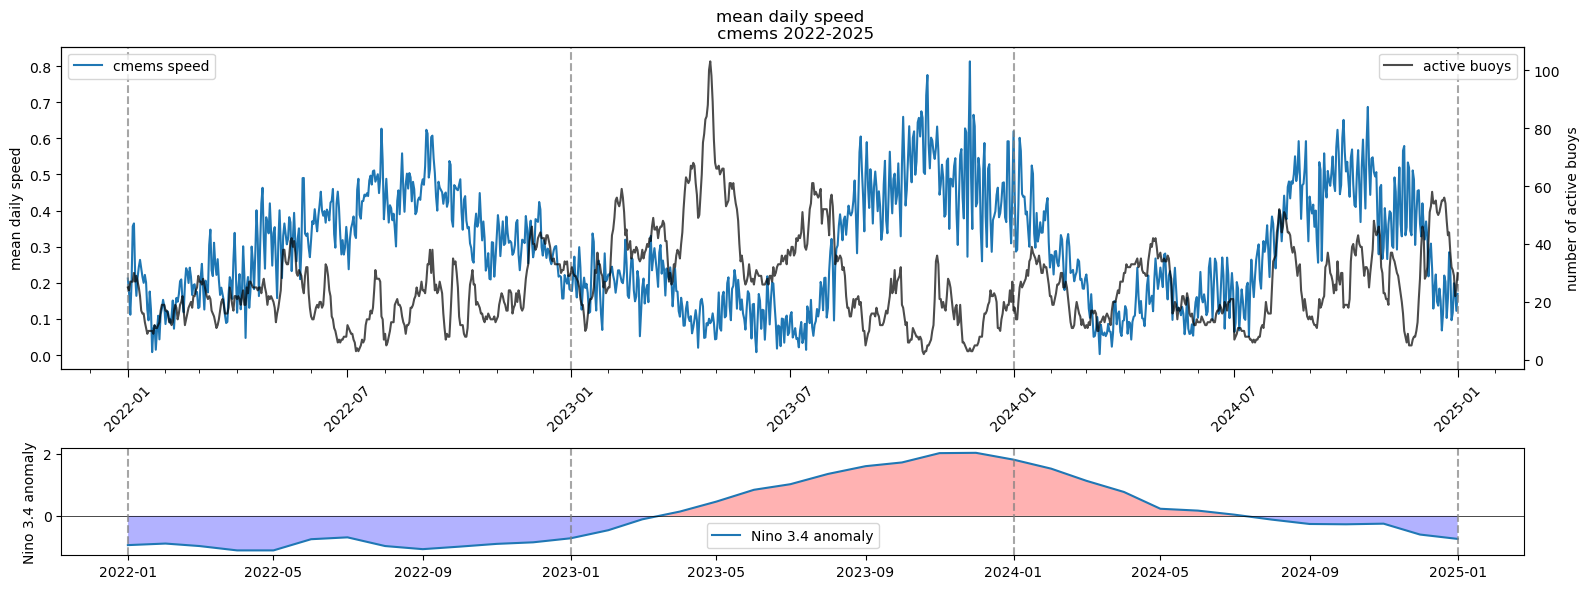

In [31]:
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import xarray as xr 

cmems =xr.open_dataset(r"Data\cmems.nc")
nina = xr.open_dataset(r"Data\nina34.anom.nc").sel(time = slice("2022-01-01", "2025-01-01"))
cmems = cmems.sel(time = slice("2022-01-01", "2025-01-01"), depth = 15.81007  )
fig = plt.figure(figsize=(16,6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1])

ax0 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

speed = np.sqrt(cmems.uo.mean(dim = ["latitude", "longitude"])**2 + cmems.vo.mean(dim = ["latitude", "longitude"])**2)
ax0.plot(cmems.time, speed, label='cmems speed')
ax0.set_ylabel('mean daily speed')

ax1 = ax0.twinx()
# daily_active.index are dates – convert to datetimes so they line up with `cmems.time`
ax1.plot(pd.to_datetime(daily_active.index), daily_active,
         color='k', label='active buoys', alpha = 0.7)
ax1.set_ylabel('number of active buoys')

# add legends for both curves
ax0.legend(loc='upper left')
ax1.legend(loc='upper right')

# major ticks every 3 months with labels, minor ticks each month (no labels)
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax0.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

ax0.tick_params(axis='x', which='major', rotation=45, length = 6)
ax0.tick_params(axis='x', which='minor', length=3)   # small ticks for months

ax0.set_ylabel("mean daily speed")
ax0.set_title("mean daily speed \n cmems 2022-2025")
#ax.set_xlim(pd.Timestamp("2023-01-01").date(),pd.Timestamp("2024-01-01").date() )
ax2.plot(nina.time, nina.value, label='Nino 3.4 anomaly')
ax2.axhline(0, color='k', lw=0.5)

# shade above/below zero
ax2.fill_between(nina.time, nina.value, 0,
                   where=nina.value >= 0,
                   facecolor='red', alpha=0.3, interpolate=True)
ax2.fill_between(nina.time, nina.value, 0,
                   where=nina.value < 0,
                   facecolor='blue', alpha=0.3, interpolate=True)

ax2.set_ylabel('Nino 3.4 anomaly')
ax2.legend()
for axi in [ax0, ax2]:
    for year in range(2022, 2026):
        axi.axvline(pd.Timestamp(f"{year}-01-01"),
                color='gray', linestyle='--', alpha=0.7)
fig.tight_layout()

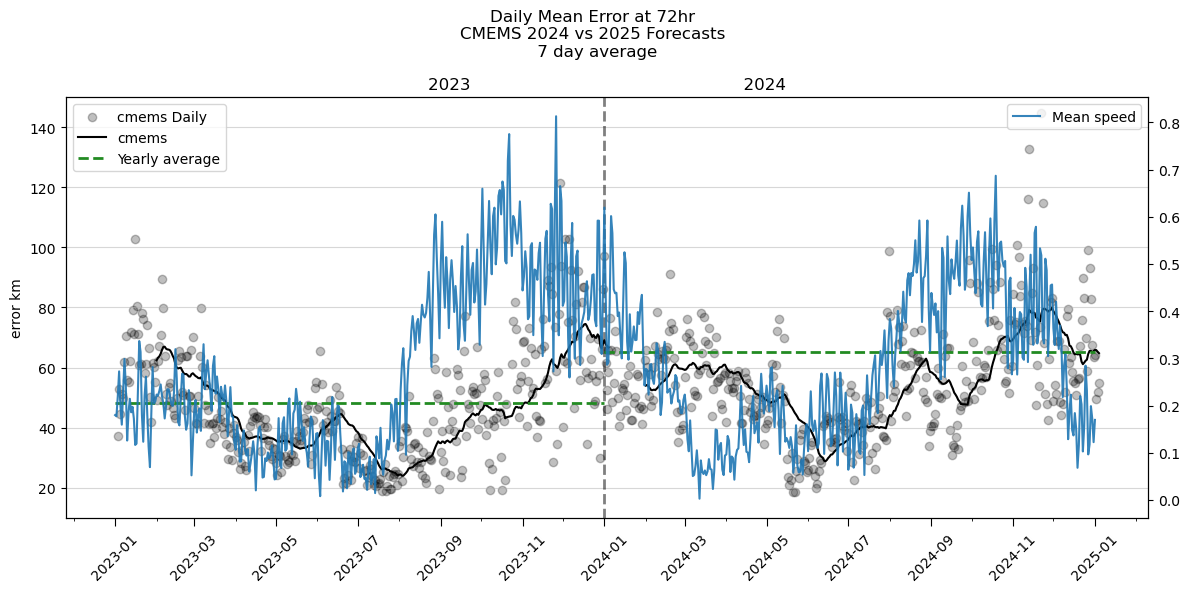

In [32]:
cmems =xr.open_dataset(r"Data\cmems.nc")
cmems = cmems.sel(time = slice("2023-01-01", "2025-01-01"), depth = 15.81007 )
speed = np.sqrt(cmems.uo.mean(dim = ["latitude", "longitude"])**2 + cmems.vo.mean(dim = ["latitude", "longitude"])**2)
fig, ax = plt.subplots( figsize = (12,6),)
ax1 = ax.twinx()
ax1.plot(cmems.time, speed, label = 'Mean speed',zorder = 0, alpha = 0.90 )
#ax1.set_ylim(-0.5, 1)
#CMEMS
ax.scatter(fctscomb.Day, fctscomb.error_km, color = "k", alpha = 0.25, label = "cmems Daily")
ax.plot(fctscomb.Day, fctscomb["rolling"], color = "k", label = "cmems")
#OSCAR 
# ax.scatter(fcts2.Day, fcts2.error_km, color = "chocolate", alpha = 0.25 ,label = "OSCAR Daily")
# ax.plot(fcts2.Day, fcts2["rolling"], color = "red", label = "OSCAR")
#NO Forecast
#ax.scatter(fcts3.Day, fcts3.error_km, color = "g", alpha = 0.25 ,label = "OSCAR Daily")
# ax[0].plot(fcts5.Day, fcts5["rolling"], color = "gray", label = "No Forecast", linestyle = "--")
# ax[1].plot(fcts3.Day, fcts3["rolling"], color = "gray", label = "No Forecast", linestyle = "--")

ax1.legend()

fig.suptitle("Daily Mean Error at 72hr \nCMEMS 2024 vs 2025 Forecasts \n 7 day average")
ax.set_ylabel("error km")
ax.set_title("2023                                                    2024")
ax.grid(axis='y', alpha=0.5)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.tick_params(axis='x', which='major', rotation=45, length = 6)
ax.vlines([pd.Timestamp("2024-01-01").date()], 0, 150, color = "k", lw = 2, ls = "--", alpha = 0.5)
ax.hlines(48.3, pd.Timestamp("2023-01-01").date(), pd.Timestamp("2024-01-01").date(),color = 'forestgreen', lw = 2, ls= "--")
ax.hlines(65.3, pd.Timestamp("2024-01-01").date(), pd.Timestamp("2025-01-01").date(), label = "Yearly average", color = "forestgreen", lw = 2, ls= "--")
ax.set_ylim(10, 150)
ax.legend()
fig.tight_layout()


##### Mounthly errors

In [33]:
fccomb = pd.concat([fc, fc4, fc6])
seasonbin = np.arange(0,13,3)
fc['month'] = fc.Time.dt.month
fc["seasonbin"] = pd.cut(fc["month"], seasonbin)
fc4['month'] = fc4.Time.dt.month
fc4["seasonbin"] = pd.cut(fc4["month"], seasonbin)
fc6['month'] = fc6.Time.dt.month
fc6["seasonbin"] = pd.cut(fc6['month'], seasonbin)
monthly2024 = fc.groupby("month")["error_km"].mean()
monthly2023 = fc4.groupby("month")["error_km"].mean()
monthly2022 = fc6.groupby("month")["error_km"].mean()
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", 'Nov', 'Dec']
season2024 = fc.groupby("seasonbin")['error_km'].mean()
season2023 = fc4.groupby("seasonbin")['error_km'].mean()
season2022 = fc6.groupby("seasonbin")['error_km'].mean()
seasons = ["Jan-Mar", 'Apr-Jun', 'Jul-Sep', 'Oct-Dec']

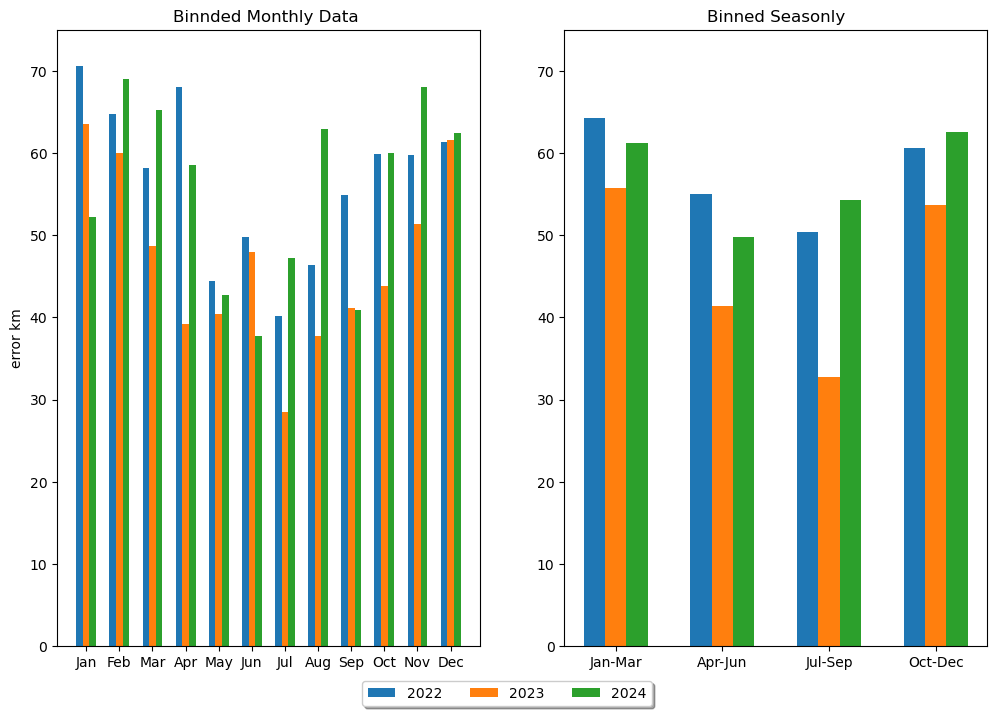

In [34]:
fig, ax = plt.subplots(1,2, figsize = (12,8))
width = 0.2
x1 = np.arange(1,13,1)
x2 = np.arange(1+width,13+width, 1)
x3 = np.arange(1+width*2,13+width*2, 1)
ax[0].bar(x1, monthly2022,width = width ,label = "2022")
ax[0].bar(x2,monthly2023,width = width , label = "2023" )
ax[0].bar(x3,monthly2024,width = width , label = "2024" )
ax[0].set_ylabel("error km")
ax[0].set_title("Binnded Monthly Data ")
ax[0].set_xticks(x1+width, months)
x4 = np.arange(1,5,1)
x5 = np.arange(1+width,5+width,1)
x6 = np.arange(1+width*2,5+width*2,1) 
ax[1].bar(x4, season2022,width = width)
ax[1].bar(x5, season2023,width = width )
ax[1].bar(x6, season2024,width = width )
ax[1].set_xticks(x4+width, seasons)
ax[1].set_title("Binned Seasonly")
for ax in [ax[1], ax[0]]:
    ax.set_ylim(0,75)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.075),
          fancybox=True, shadow=True, ncol=5)

### Creating forecast based off of initial error

In [35]:
oscar_merged = merge_forecast_true(fc1, longlist)
cmems_merged = merge_forecast_true(fc, longlist)
##remove duplicate forecasts start at the same time 
cmems_merged["starttime"] = cmems_merged['Time']- pd.to_timedelta(cmems_merged["leadtime"],unit = "hours").dt.round("min")
oscar_merged["starttime"] = oscar_merged['Time']- pd.to_timedelta(oscar_merged["leadtime"], unit="hours").dt.round("min")

## calcuate inital angle for both
oscar_merged = calc_projection_initial_angle(oscar_merged, "_OSCAR")
cmems_merged = calc_projection_initial_angle(cmems_merged)
oscar_merged = calc_projection_initial_angle(oscar_merged)
cmems_merged = calc_projection_initial_angle(cmems_merged, "_OSCAR")
oscar_merged = calc_intial_speed_dif(oscar_merged, "_OSCAR")
cmems_merged = calc_intial_speed_dif(cmems_merged)
oscar_merged = calc_intial_speed_dif(oscar_merged)
cmems_merged = calc_intial_speed_dif(cmems_merged, "_OSCAR")


In [36]:
## For each forecast decide which one is better based off of initial angle. 
def lower_initial_angle(group):
    if group.empty:
        return group

    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_angle"] 
    oscari = group.at[idx, "initial_angle_OSCAR"] 

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g

def lower_porjection_angle(group):
    if group.empty:
        return group
    
    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "projection"]
    oscari = group.at[idx, "projection_OSCAR"]

    if oscari < 0 and (cmemsi > oscari): 
        choice = "cmems"
    else: 
        choice = "OSCAR"
    g = group.copy()
    g["best_model"] = choice
    return g

def lower_speed_dif(group):
    if group.empty:
        return group
    
    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_speed_dif_mag"]
    oscari = group.at[idx, "initial_speed_dif_mag_OSCAR"]

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g


cmems_grouped = cmems_merged.groupby(["BuoyID", "starttime"]).apply(lower_speed_dif)
OSCAR_grouped = oscar_merged.groupby(["BuoyID", "starttime"]).apply(lower_speed_dif)
#cmems_grouped.reset_index().query("leadtime == 0").query("best_model == 'OSCAR'").shape[0]

cmems_forecasts = cmems_grouped.reset_index().query("best_model == 'cmems'")
oscar_forecasts = OSCAR_grouped.reset_index().query("best_model == 'OSCAR'")
oscar_forecasts["initial_angle_used"] = oscar_forecasts["initial_angle_OSCAR"]
cmems_forecasts["initial_angle_used"] = cmems_forecasts["initial_angle"]
oscar_forecasts["projection_used"] = oscar_forecasts["projection_OSCAR"]
cmems_forecasts["projection_used"] = cmems_forecasts["projection"]

ia_forecast = pd.concat([oscar_forecasts,cmems_forecasts])

In [37]:
### now want to compair to the optimal forecasting method and see how many we have gotten right( picked cmems or oscar correctly) 

fc_opt = merge_forecast_true(fc2, longlist)
fc_opt = add_starttime(fc_opt)
# get unique groups as a dataframe
grouped_opt = fc_opt[["BuoyID", "starttime", "model"]].drop_duplicates().reset_index(drop=True)
grouped_ia = ia_forecast[["BuoyID", "starttime", "best_model"]].drop_duplicates().reset_index(drop =True) 
print(len(grouped_ia), len(grouped_opt))
# Find groups that appear in both dataframes
merged_groups = pd.merge(grouped_ia, grouped_opt, on=['BuoyID', 'starttime'], how='inner')
common_groups = merged_groups[['BuoyID', 'starttime']].drop_duplicates()
print(f"Number of groups in both: {len(common_groups)}")


8429 8429
Number of groups in both: 8429


In [38]:
#compair two comulms of the data set and produce a new column with 1 being the values in that row  are the same and 
merged_groups["correct"] = (merged_groups["best_model"] == merged_groups["model"]).astype(int)
corect_forecasts = merged_groups[ merged_groups.correct == 1]
incorrect_forecasts = merged_groups[merged_groups.correct != 1]
print(f"Percent of correct model chosen {corect_forecasts.shape[0]/merged_groups.shape[0]}")
print(f"percent cmems {len(grouped_ia[grouped_ia.best_model == 'cmems'])/len(grouped_ia)} ")

Percent of correct model chosen 0.6315102621900581
percent cmems 0.4495195159568158 


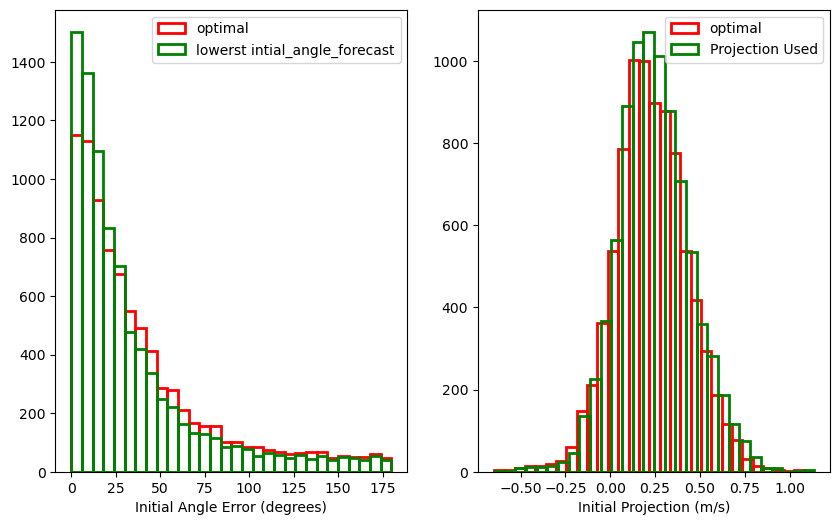

In [39]:
## hsitorgram like above of distribution of intial angle errors. 
fc_optia = fc_opt_saved.copy()
fc_optia = fc_optia.query("leadtime == 0")
intial_times_ia = ia_forecast.query("leadtime == 0")
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].hist(fc_optia.initial_angle, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax[0].hist(intial_times_ia.initial_angle_used, 30, fill= None, edgecolor = "g", lw =2, label = "lowerst intial_angle_forecast")
ax[0].set_xlabel("Initial Angle Error (degrees)")
ax[0].legend()
ax[1].hist(fc_optia.projection, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax[1].hist(intial_times_ia.projection_used, 30, fill= None, edgecolor = "g", lw =2, label = "Projection Used")
ax[1].set_xlabel("Initial Projection (m/s)")
ax[1].legend()

In [40]:
### Year 2023 vs year 2024
fc2024 =  add_starttime(merge_forecast_true(fc, longlist))
fc2023 = add_starttime(merge_forecast_true(fc4, longlist))
fc2022 = add_starttime(merge_forecast_true(fc6, longlist))

fc2024 = calc_projection_initial_angle(fc2024)
fc2023 = calc_projection_initial_angle(fc2023)
fc2022 = calc_projection_initial_angle(fc2022)
fc2024 = calc_intial_speed_dif(fc2024)
fc2023 = calc_intial_speed_dif(fc2023)
fc2022 = calc_intial_speed_dif(fc2022)
fc2023i = fc2023.query('leadtime == 0')
fc2024i = fc2024.query('leadtime == 0')
fc2024i["speed"] = (fc2024.x_speed**2 +fc2024.y_speed**2)**(1/2)
fc2023i["speed"] = (fc2023.x_speed**2 +fc2023.y_speed**2)**(1/2)

Text(0, 0.5, 'Probilty Density ')

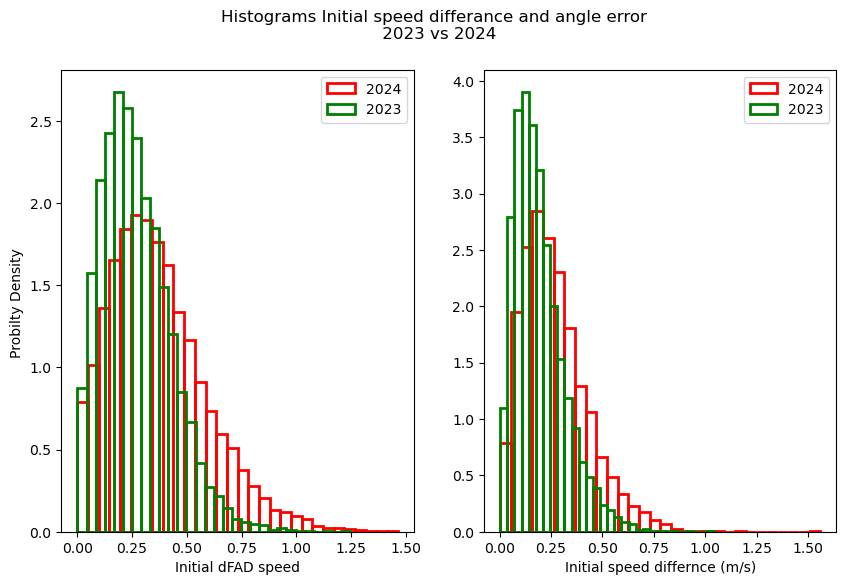

In [41]:
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].hist(fc2024i.speed, 30, fill= None, edgecolor = "r", lw =2, label = "2024", density = True)
ax[0].hist(fc2023i.speed, 30, fill= None, edgecolor = "g", lw =2, label = "2023", density = True)
ax[0].set_xlabel("Initial dFAD speed")
ax[0].legend()
ax[1].hist(fc2024i.initial_speed_dif_mag, 30, fill= None, edgecolor = "r", lw =2, label = "2024", density = True)
ax[1].hist(fc2023i.initial_speed_dif_mag, 30, fill= None, edgecolor = "g", lw =2, label = "2023", density = True)
ax[1].set_xlabel("Initial speed differnce (m/s)")
ax[1].legend()
fig.suptitle("Histograms Initial speed differance and angle error \n 2023 vs 2024")
ax[0].set_ylabel("Probilty Density ")

In [42]:
### saving initial angle forecasts 
ia_save = ia_forecast[["BuoyID", "Time", "lat_true", "lon_true", "lon_forcast", "lat_forcast", "leadtime", "best_model", "initial_angle_used"]]
ia_save.to_csv(r"Parcels\saved_output\intial_speed_dif.csv")

In [43]:
ia_forecast_less90 = ia_forecast[ia_forecast["initial_angle_used"] < 90]
ia_forecast_less90.to_csv("Parcels\saved_output\initial_angle_forecasts_less90.csv")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\czerfass\AppData\Local\Temp\2\ipykernel_20244\2265086388.py:2: SyntaxWarning: invalid escape sequence '\s'
  ia_forecast_less90.to_csv("Parcels\saved_output\initial_angle_forecasts_less90.csv")


### Back testing predictions based on iniital speeds difference

In [44]:
## Generate regresssion based only on intiall speed difference
def quantile_regreession_oneleatime_and_q(data, q):
    """Data is at one specific leadtiem, q is what quantile (0-1)"""
    model = smf.quantreg("error_km ~ initial_speed_dif_mag", data)
    model = model.fit(q=q)
    return model

def quantile_regression_one_leadtime(data,qstep = 0.05):
    qrange = np.arange(0,1,qstep)
    qrange = qrange[1:]
    print(qrange)
    output = pd.DataFrame(columns = ["q" , "Intercept", 'initial_speed_dif_mag'])
    for q in qrange:
        model = quantile_regreession_oneleatime_and_q(data,q)
        model = model.params.to_frame().T
        model["q"] = q
        output = pd.concat([output, model])
    return output

target_leadtime = 3*24 -2
target_leadtime_upper = target_leadtime + 12
fc202472 = fc2024.query("leadtime > @target_leadtime")
fc202472 = fc202472.query('leadtime < @target_leadtime_upper')
fc202472 = fc202472.drop_duplicates(["BuoyID", "starttime"]).reset_index(drop = True)
params = quantile_regression_one_leadtime(fc202472, 0.05)





[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


In [45]:
# take the error for that forecast, bin it into what quartile it should of gone into. look at frequency of these quartiles. 
def quantile_bin(row): 
    params["results"] = params.Intercept + row.initial_speed_dif_mag*params.initial_speed_dif_mag 
    valid = params[params.results >= row.error_km]
    if len(valid) == 0:
        return 1
    else:
        return valid.q.min()


fc202472["q"] = fc202472.apply(quantile_bin, axis  =1)
qlist = fc202472.groupby("q")["q"].count()

In [46]:
def analysize_regression(data, leadtime, regressiondata= None, qstep = 0.05, speedbin:list = None):
    target_leadtime = leadtime
    target_leadtime_upper = target_leadtime + 12
    datalt = data.query("leadtime > @target_leadtime")
    datalt = datalt.query('leadtime < @target_leadtime_upper')
    datalt = datalt.drop_duplicates(["BuoyID", "starttime"]).reset_index(drop = True)
    if regressiondata is None:
        params = quantile_regression_one_leadtime(datalt, 0.05)
    else: 
        regressiondata = regressiondata.query("leadtime > @target_leadtime")
        regressiondata = regressiondata.query('leadtime < @target_leadtime_upper')
        regressiondata = regressiondata.drop_duplicates(["BuoyID", "starttime"]).reset_index(drop = True)
        params = quantile_regression_one_leadtime(regressiondata, 0.05)

    if speedbin is not None: 
        datalt = datalt[datalt.initial_speed_dif_mag > speedbin[0]]
        datalt = datalt[datalt.initial_speed_dif_mag < speedbin[1]]
    datalt["q"] = datalt.apply(quantile_bin, axis  =1)
    qlist = datalt.groupby("q")["q"].count()
    return qlist, len(datalt)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


Text(0.5, 1.0, 'Testing prediction of regression forecasting\n 2024 regression tested on 2023 data')

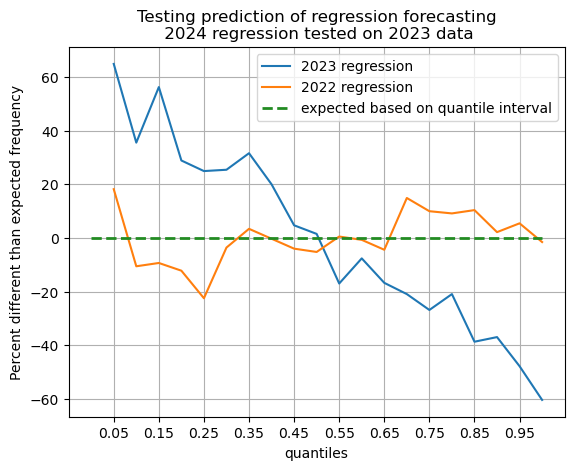

In [47]:
fig, ax = plt.subplots()
speedbins = np.arange(0,1,0.25)
qstep = 0.05
# for i in range(len(speedbins)-1):
#     qlist, length = analysize_regression(fc2024, 70,qstep = qstep, speedbin= [speedbins[i],speedbins[i+1]])
#     ax.plot(qlist.index, qlist.values.cumsum()/length, label = f"inital Speed Dif: {speedbins[i]} - {speedbins[i+1]}")

qlist, length = analysize_regression(fc2023, 70,qstep = qstep, regressiondata= fc2024)
ax.plot(qlist.index, (qlist.values - length*qstep)/(length*qstep)*100, label = f"2023 regression")
qlist, length = analysize_regression(fc2022, 70,qstep = qstep, regressiondata= fc2024)
ax.plot(qlist.index, (qlist.values - length*qstep)/(length*qstep)*100, label = f"2022 regression")
#ax.plot(qlist.index, qlist.index, color = "k", alpha = 0.75, lw = 2)
ax.grid()
ax.set_xlabel("quantiles")
ax.set_ylabel("Percent different than expected frequency")
ax.set_xticks(qlist.index[::2])
ax.hlines(qstep, 0, 1, color = "forestgreen", lw= 2, ls= '--', label = 'expected based on quantile interval')
ax.legend()
ax.set_title("Testing prediction of regression forecasting\n 2024 regression tested on 2023 data")


### Calculating model spread. 

- compare the spread for a target segment
- Need to compare the two models and calculate the spread

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


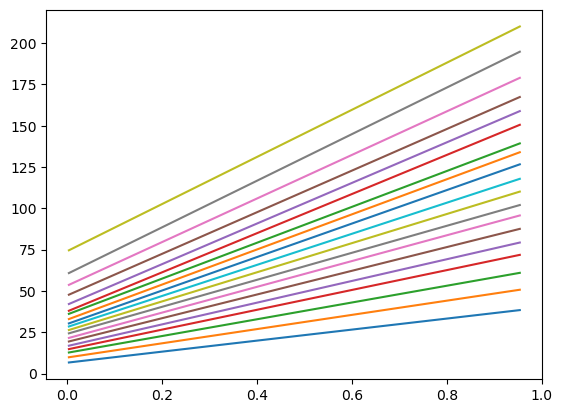

In [48]:
model = smf.quantreg("error_km ~  initial_angle+ initial_speed_dif_mag ", merged_start)
quartiles_range = np.linspace(0.05, 0.95, 19)
print(quartiles_range)
initial_speed_dif_mag = np.arange(merged_start.initial_speed_dif_mag.min(), merged_start.initial_speed_dif_mag.max(), 0.05)
target_angle = 60
models = []

fig, ax = plt.subplots()
for n in quartiles_range: 
    res = model.fit(q=n)
    models.append(res)
    y = res.params["Intercept"] + res.params["initial_speed_dif_mag"]*initial_speed_dif_mag + res.params["initial_angle"]*target_angle
    ax.plot(initial_speed_dif_mag, y, label =f"Percentile {n:.2f}")

In [121]:
### errors as a fucntion of latitude 
def true_lat_lon_start_possition(forecast:pd.DataFrame):
    forecast = forecast.sort_values("leadtime")
    forecast = add_starttime(forecast)
    forecast["initial_lat"] = forecast.groupby(["BuoyID", "starttime"])['lat_true'].transform("first")
    forecast["initial_lon"] = forecast.groupby(["BuoyID", "starttime"])['lon_true'].transform("first")
    return forecast

def lat_lon_errors(forecast: pd.DataFrame):
    forecast = true_lat_lon_start_possition(forecast)
    lat_bins = np.arange(4.5, 7.8, 0.25)
    lon_bins = np.arange(-163.7, -160.6, 0.25)
    forecast["lat_bin"] = pd.cut(forecast.initial_lat, lat_bins)
    forecast["lon_bin"] = pd.cut(forecast.initial_lon, lon_bins)
    target_leatime = 70
    target_leatime_end = target_leatime +12
    forecast72 = forecast.query("leadtime > @target_leatime")
    forecast72 = forecast72.query("leadtime < @target_leatime_end")
    lat_errors = forecast72.groupby("lat_bin")["error_km"].mean()
    lon_errors = forecast72.groupby("lon_bin")["error_km"].mean()
    lat_count = forecast72.groupby("lat_bin")["error_km"].count()
    lon_count = forecast72.groupby("lon_bin")["error_km"].count()
    return lat_errors, lon_errors, lat_bins, lon_bins, lat_count, lon_count

In [163]:
lat_errors2 , lon_errors2, lat_bins2, lon_bins2,lat_count2, lon_count2 = lat_lon_errors(fc6)
lat_errors3 , lon_errors3, lat_bins3, lon_bins3,lat_count3, lon_count3 = lat_lon_errors(fc4)
lat_errors4 , lon_errors4, lat_bins4, lon_bins4,lat_count4, lon_count4 = lat_lon_errors(fc)
meanerror2 = fc6.error_km.mean()
meanerror3 = fc4.error_km.mean()
meanerror4 = fc.error_km.mean()


In [141]:
lat_count2.max()

1114

C:\Users\czerfass\AppData\Local\Temp\2\ipykernel_20244\2284970915.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


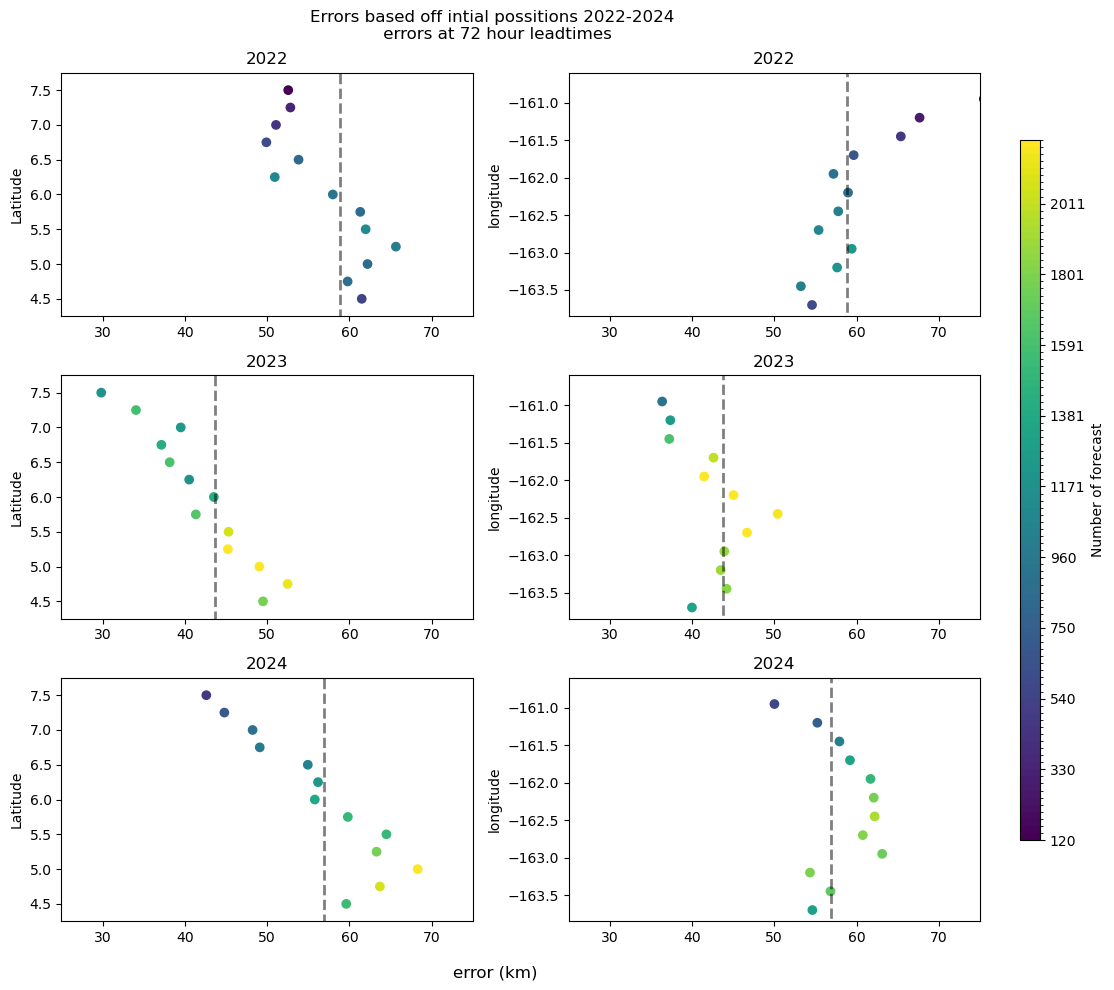

In [176]:
from matplotlib import cm, colors
fig, ax = plt.subplots(3,2, figsize = (10,10))
vmin, vmax = 120, 2200 # Ensure consistent color mapping across frames
levels = np.linspace(vmin, vmax, 100)
cmap = cm.viridis
norm = colors.BoundaryNorm(levels, cmap.N)

cbr = ax[0,0].scatter(lat_errors2.values, lat_bins2[lat_errors2.index.codes],c= lat_count2.values, cmap = cmap, norm = norm)
ax[0,1].scatter(lon_errors2.values, lon_bins2[lon_errors2.index.codes],c= lon_count2.values, cmap = cmap, norm = norm)

ax[1,0].scatter(lat_errors3.values, lat_bins3[lat_errors3.index.codes],c= lat_count3.values, cmap = cmap, norm = norm)
ax[1,1].scatter(lon_errors3.values, lon_bins3[lon_errors3.index.codes],c= lon_count3.values, cmap = cmap, norm = norm)

ax[2,0].scatter(lat_errors4.values, lat_bins4[lat_errors4.index.codes],c= lat_count4.values, cmap = cmap, norm = norm)
ax[2,1].scatter(lon_errors4.values, lon_bins4[lon_errors4.index.codes],c= lon_count4.values, cmap = cmap, norm = norm)

means = [meanerror2, meanerror3, meanerror4]
titles = ["2022", '2023', '2024']
for i, axi in enumerate([ax[0,0], ax[1,0], ax[2,0]]):
    axi.vlines(means[i], 4,8, color = "k", lw = 2, ls = "--", alpha = 0.5)
    axi.set(xlim = [25,75],ylim =[4.25,7.75], ylabel = "Latitude",  title = titles[i])

for i, axi in enumerate([ax[0,1], ax[1,1], ax[2,1]]):
    axi.vlines(means[i], -164, -160,  color = "k", lw = 2, ls = "--", alpha = 0.5)
    axi.set(xlim = [25,75],ylim = [-163.85, -160.6], ylabel = "longitude", title = titles[i])

ax[0,0].set(xlim = [25,75], ylabel = "Latitude",  title = "2022")
ax[0,1].set(xlim = [25,75], ylabel = "longitude", title = "2022")
ax[1,0].set(xlim = [25,75], ylabel = "Latitude",  title = "2023")
ax[1,1].set(xlim = [25,75], ylabel = "longitude", title = "2023")
ax[2,0].set(xlim = [25,75], ylabel = "Latitude",  title = "2024")
ax[2,1].set(xlim = [25,75], ylabel = "longitude", title = "2024")
cbar_ax = fig.add_axes([1.025, 0.15, 0.02, 0.7]) 
fig.colorbar(cbr, cax=cbar_ax, fraction = 0.1, label = "Number of forecast")
fig.supxlabel("error (km)")
fig.suptitle("Errors based off intial possitions 2022-2024 \n errors at 72 hour leadtimes")
fig.tight_layout()